<a href="https://colab.research.google.com/github/vanshika704/celebal/blob/main/week6_vanshika.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

(60000, 28, 28)
Training images: (60000, 28, 28)
Testing images: (10000, 28, 28)
<class 'numpy.ndarray'>


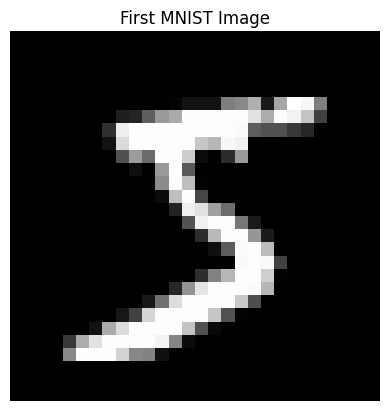

Minimum pixel value: 0.0
Maximum pixel value: 1.0


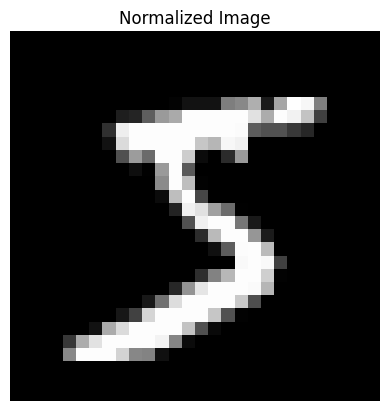

Noisy image minimum pixel value: 0.0
Noisy image maximum pixel value: 1.0


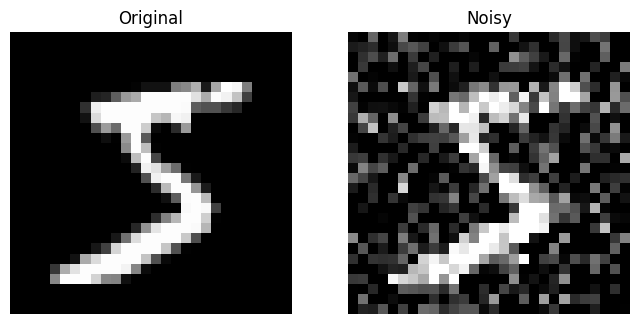

In [8]:

# Step 2: Load the MNIST dataset , the originial kaggle dataset was 38 mb so , we use the same dataset that tf provides

(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
print(x_train.shape)
print("Training images:", x_train.shape)
print("Testing images:", x_test.shape)
print(type(x_train))

plt.imshow(x_train[0], cmap="gray")
plt.title("First MNIST Image")
plt.axis("off")
plt.show()

# Step 3: Normalize the images

x_train = x_train.astype("float32")
x_test = x_test.astype("float32")

x_train = x_train / 255.0
x_test = x_test / 255.0

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

plt.imshow(x_train[0], cmap="gray")
plt.title("Normalized Image")
plt.axis("off")
plt.show()


# Step 4: Add Gaussian Noise

# Controls how much noise is added
noise_factor = 0.3

# Generate noisy training images
x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

# Generate noisy testing images
x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

# Keep all pixel values between 0 and 1
x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_test_noisy = np.clip(x_test_noisy, 0.0, 1.0)

# Check the range after adding noise
print("Noisy image minimum pixel value:", x_train_noisy.min())
print("Noisy image maximum pixel value:", x_train_noisy.max())




# visualize image
plt.figure(figsize=(8, 4))

# Original image
plt.subplot(1, 2, 1)
plt.imshow(x_train[0], cmap="gray")
plt.title("Original")
plt.axis("off")

# Noisy image
plt.subplot(1, 2, 2)
plt.imshow(x_train_noisy[0], cmap="gray")
plt.title("Noisy")
plt.axis("off")

plt.show()

In [9]:
# Step 5: Reshape images to include the channel dimension

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

x_train_noisy = x_train_noisy.reshape(-1, 28, 28, 1)
x_test_noisy = x_test_noisy.reshape(-1, 28, 28, 1)

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)

print("Noisy training shape:", x_train_noisy.shape)
print("Noisy testing shape:", x_test_noisy.shape)

Training shape: (60000, 28, 28, 1)
Testing shape: (10000, 28, 28, 1)
Noisy training shape: (60000, 28, 28, 1)
Noisy testing shape: (10000, 28, 28, 1)


In [16]:
# ==========================
# Step 6: Build Autoencoder
# ==========================

import tensorflow as tf

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D
)

from tensorflow.keras.models import Model

print("TensorFlow Version:", tf.__version__)

# --------------------------
# Input Layer
# --------------------------

input_img = Input(shape=(28, 28, 1))

# ==========================
# Encoder
# ==========================

# First Convolution
x = Conv2D(
    filters=32,
    kernel_size=(3, 3),
    activation="relu",
    padding="same"
)(input_img)

# Downsample (28x28 -> 14x14)
x = MaxPooling2D(
    pool_size=(2, 2),
    padding="same"
)(x)

# Second Convolution
x = Conv2D(
    filters=16,
    kernel_size=(3, 3),
    activation="relu",
    padding="same"
)(x)

# Downsample (14x14 -> 7x7)
encoded = MaxPooling2D(
    pool_size=(2, 2),
    padding="same"
)(x)

# ==========================
# Decoder
# ==========================

# First Decoder Convolution
x = Conv2D(
    filters=16,
    kernel_size=(3, 3),
    activation="relu",
    padding="same"
)(encoded)

# Upsample (7x7 -> 14x14)
x = UpSampling2D(
    size=(2, 2)
)(x)

# Second Decoder Convolution
x = Conv2D(
    filters=32,
    kernel_size=(3, 3),
    activation="relu",
    padding="same"
)(x)

# Upsample (14x14 -> 28x28)
x = UpSampling2D(
    size=(2, 2)
)(x)

# Output Layer
decoded = Conv2D(
    filters=1,
    kernel_size=(3, 3),
    activation="sigmoid",
    padding="same"
)(x)

# ==========================
# Create Model
# ==========================

autoencoder = Model(
    inputs=input_img,
    outputs=decoded
)

# Display Model Summary
autoencoder.summary()

TensorFlow Version: 2.20.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
autoencoder.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 104s 216ms/step - loss: 0.1667 - val_loss: 0.0992
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 99s 211ms/step - loss: 0.0947 - val_loss: 0.0906
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 213ms/step - loss: 0.0895 - val_loss: 0.0873
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 99s 210ms/step - loss: 0.0874 - val_loss: 0.0857
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 144s 214ms/step - loss: 0.0861 - val_loss: 0.0851
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 215ms/step - loss: 0.0850 - val_loss: 0.0843
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 214ms/step - loss: 0.0842 - val_loss: 0.0833
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 140s 210ms/step - loss: 0.0836 - val_loss: 0.0826
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 211ms/step - loss: 0.0831 - val_loss: 0.0824
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 98s 208ms/step - loss: 0.0827 - val_loss: 0.0818


In [18]:
# ==========================
# Step 8: Train the Model
# ==========================

history = autoencoder.fit(
    x=x_train_noisy,
    y=x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 101s 216ms/step - loss: 0.0824 - val_loss: 0.0815
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 100s 212ms/step - loss: 0.0821 - val_loss: 0.0814
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 99s 212ms/step - loss: 0.0819 - val_loss: 0.0811
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 100s 214ms/step - loss: 0.0816 - val_loss: 0.0811
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 99s 211ms/step - loss: 0.0814 - val_loss: 0.0807
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 99s 212ms/step - loss: 0.0812 - val_loss: 0.0806
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 100s 214ms/step - loss: 0.0810 - val_loss: 0.0803
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 99s 211ms/step - loss: 0.0809 - val_loss: 0.0804
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 98s 209ms/step - loss: 0.0807 - val_loss: 0.0800
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 100s 214ms/step - loss: 0.0806 - val_loss: 0.0801


In [19]:
# ==========================
# Step 9: Denoise the Images
# ==========================

decoded_images = autoencoder.predict(x_test_noisy)

print("Shape of decoded images:", decoded_images.shape)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
Shape of decoded images: (10000, 28, 28, 1)


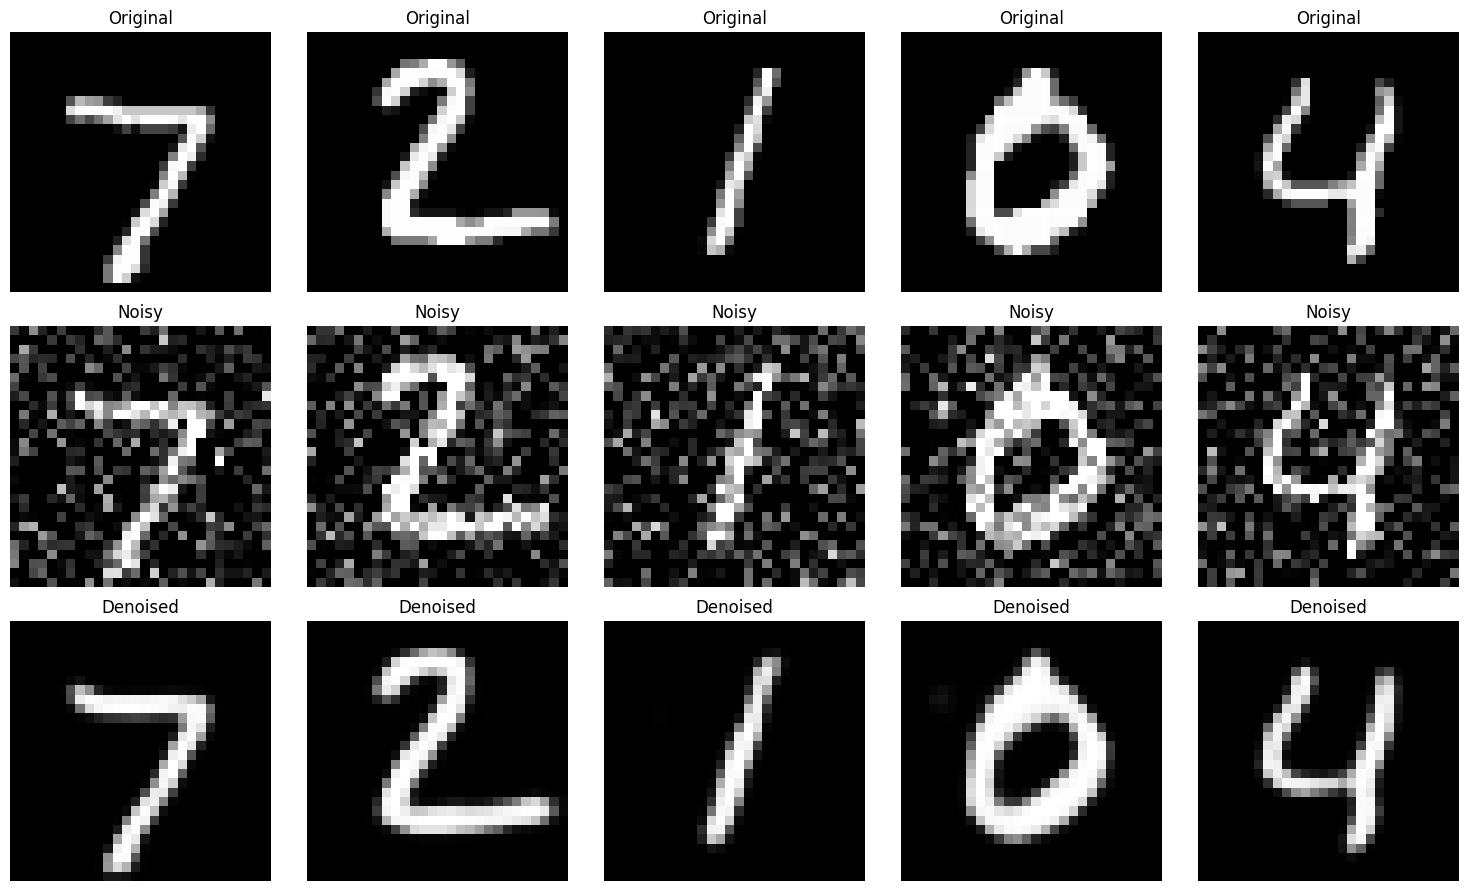

In [20]:
# ==========================
# Step 10: Visualize Results
# ==========================

n = 5  # Number of images to display

plt.figure(figsize=(15, 9))

for i in range(n):

    # -------------------------
    # Original Image
    # -------------------------
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # -------------------------
    # Noisy Image
    # -------------------------
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # -------------------------
    # Denoised Image
    # -------------------------
    plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(decoded_images[i].reshape(28, 28), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()

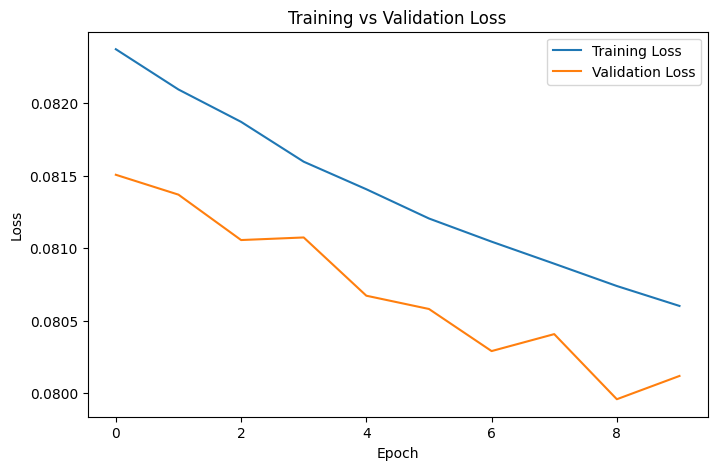

In [21]:
# ==========================
# Step 11: Plot Loss Curve
# ==========================

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()